In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
# Dataset source: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
# Download CSVs and place them in data/raw/ before running
orders = pd.read_csv("data/raw/olist_orders_dataset.csv")
customers = pd.read_csv("data/raw/olist_customers_dataset.csv")
items = pd.read_csv("data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("data/raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("data/raw/product_category_name_translation.csv")
geolocation = pd.read_csv("data/raw/olist_geolocation_dataset.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
# Initial exploration
datasets = {
    "orders": orders,
    "customers": customers,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
    "geolocation": geolocation
}

for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    print(f"Columns: {list(df.columns)}")
    print()

=== orders ===
Rows: 99441 | Columns: 8
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== customers ===
Rows: 99441 | Columns: 5
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

=== items ===
Rows: 112650 | Columns: 7
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

=== payments ===
Rows: 103886 | Columns: 5
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

=== reviews ===
Rows: 99224 | Columns: 7
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

=== products ===
Rows: 32951 | Columns: 9
Columns: ['product_id', 'product_category_name', 'product_name_lengh

In [4]:
# Check data types and nulls
for name, df in datasets.items():
    print(f"=== {name} ===")
    print(df.dtypes)
    print(f"Nulls:\n{df.isnull().sum()}")
    print()

=== orders ===
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Nulls:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== customers ===
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
Nulls:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state       

In [5]:
# Data Cleaning

# 1. Convert date columns to datetime
date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col])

# 2. Convert dates in items and reviews
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

# 3. Fill null product categories
products['product_category_name'] = products['product_category_name'].fillna('unknown')

print("Cleaning done")

Cleaning done


In [6]:
# Verify cleaning
print("=== orders dtypes ===")
print(orders[date_cols_orders].dtypes)

print("\n=== products null categories ===")
print(products['product_category_name'].isnull().sum())

=== orders dtypes ===
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

=== products null categories ===
0


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [8]:
# Create late delivery column
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_estimated_delivery_date']
).dt.days

orders['is_late'] = orders['delivery_delay_days'] > 0

print(orders[['order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'is_late']].head(10))

  order_delivered_customer_date order_estimated_delivery_date  \
0           2017-10-10 21:25:13                    2017-10-18   
1           2018-08-07 15:27:45                    2018-08-13   
2           2018-08-17 18:06:29                    2018-09-04   
3           2017-12-02 00:28:42                    2017-12-15   
4           2018-02-16 18:17:02                    2018-02-26   
5           2017-07-26 10:57:55                    2017-08-01   
6                           NaT                    2017-05-09   
7           2017-05-26 12:55:51                    2017-06-07   
8           2017-02-02 14:08:10                    2017-03-06   
9           2017-08-16 17:14:30                    2017-08-23   

   delivery_delay_days  is_late  
0                 -8.0    False  
1                 -6.0    False  
2                -18.0    False  
3                -13.0    False  
4                -10.0    False  
5                 -6.0    False  
6                  NaN    False  
7           

In [9]:
# Save clean orders
orders.to_csv("data/clean/orders_clean.csv", index=False)

print("orders_clean.csv saved")

orders_clean.csv saved


In [10]:
print("=== Late deliveries ===")
print(orders['is_late'].value_counts())
print(f"\n% late: {round(orders['is_late'].mean() * 100, 2)}%")

=== Late deliveries ===
is_late
False    92906
True      6535
Name: count, dtype: int64

% late: 6.57%


In [11]:
orders.to_csv("data/clean/orders_clean.csv", index=False)
print("Saved")

Saved


In [12]:
# Q8 - Customer and Revenue Evolution 2016-2018

# Merge orders with payments
orders_payments = orders.merge(payments, on='order_id', how='left')

# Extract year and month
orders_payments['year_month'] = orders_payments['order_purchase_timestamp'].dt.to_period('M')

# Monthly aggregation
monthly = orders_payments.groupby('year_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index()

monthly['year_month'] = monthly['year_month'].astype(str)

print(monthly.head(10))

  year_month  total_orders  total_revenue
0    2016-09             4         252.24
1    2016-10           324       59090.48
2    2016-12             1          19.62
3    2017-01           800      138488.04
4    2017-02          1780      291908.01
5    2017-03          2682      449863.60
6    2017-04          2404      417788.03
7    2017-05          3700      592918.82
8    2017-06          3245      511276.38
9    2017-07          4026      592382.92


In [13]:
print(monthly.to_string())

   year_month  total_orders  total_revenue
0     2016-09             4         252.24
1     2016-10           324       59090.48
2     2016-12             1          19.62
3     2017-01           800      138488.04
4     2017-02          1780      291908.01
5     2017-03          2682      449863.60
6     2017-04          2404      417788.03
7     2017-05          3700      592918.82
8     2017-06          3245      511276.38
9     2017-07          4026      592382.92
10    2017-08          4331      674396.32
11    2017-09          4285      727762.45
12    2017-10          4631      779677.88
13    2017-11          7544     1194882.80
14    2017-12          5673      878401.48
15    2018-01          7269     1115004.18
16    2018-02          6728      992463.34
17    2018-03          7211     1159652.12
18    2018-04          6939     1160785.48
19    2018-05          6873     1153982.15
20    2018-06          6167     1023880.50
21    2018-07          6292     1066540.75
22    2018-

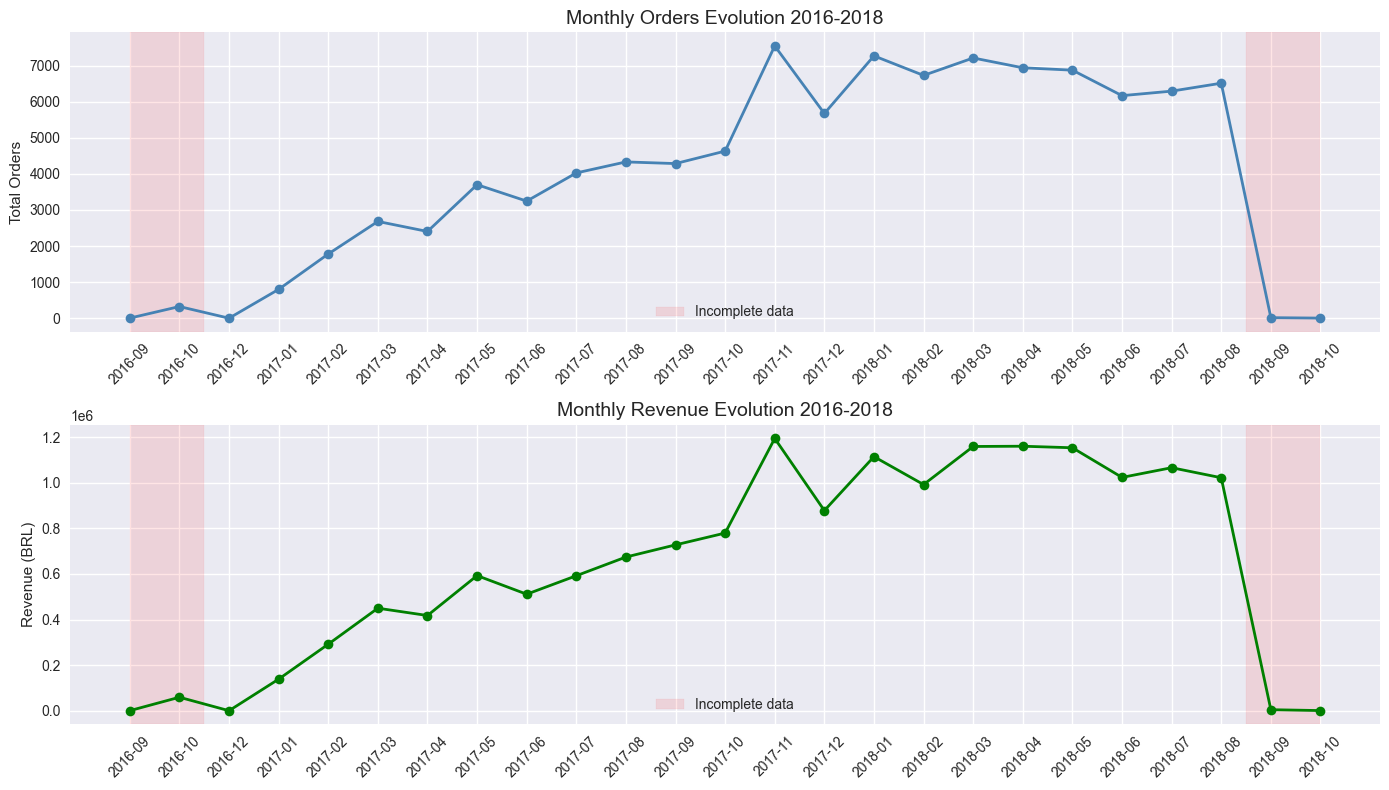

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Orders evolution
ax1.plot(monthly['year_month'], monthly['total_orders'], color='steelblue', marker='o', linewidth=2)
ax1.set_title('Monthly Orders Evolution 2016-2018', fontsize=14)
ax1.set_ylabel('Total Orders')
ax1.tick_params(axis='x', rotation=45)
ax1.axvspan(0, 1.5, alpha=0.1, color='red', label='Incomplete data')
ax1.axvspan(22.5, 24, alpha=0.1, color='red')
ax1.legend()

# Revenue evolution
ax2.plot(monthly['year_month'], monthly['total_revenue'], color='green', marker='o', linewidth=2)
ax2.set_title('Monthly Revenue Evolution 2016-2018', fontsize=14)
ax2.set_ylabel('Revenue (BRL)')
ax2.tick_params(axis='x', rotation=45)
ax2.axvspan(0, 1.5, alpha=0.1, color='red', label='Incomplete data')
ax2.axvspan(22.5, 24, alpha=0.1, color='red')
ax2.legend()

plt.tight_layout()
plt.savefig('images/q8_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## Q8 - Customer and Revenue Evolution 2016-2018

**Key Insights:**
- Orders grew from 800 in January 2017 to 7,269 in January 2018 — 9x growth in one year
- Revenue followed the same trend, growing from $138K to $1.1M monthly
- November 2017 peak (7,544 orders) driven by Black Friday / Black November in Brazil
- September 2016 and October 2018 show incomplete data and should be excluded from trend analysis
- Growth stabilized in 2018 between 6,000-7,500 orders/month suggesting market maturity

In [15]:
# Q9 - Late deliveries impact on one-time buyers

# Merge orders with customers
orders_customers = orders.merge(customers, on='customer_id', how='left')

# Count orders per unique customer
customer_orders = orders_customers.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'nunique'),
    late_deliveries=('is_late', 'sum')
).reset_index()

# Classify customers
customer_orders['is_one_time'] = customer_orders['total_orders'] == 1

# Compare late deliveries between one-time and repeat customers
result = customer_orders.groupby('is_one_time').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_late_deliveries=('late_deliveries', 'mean')
).reset_index()

result['is_one_time'] = result['is_one_time'].map({True: 'One-time', False: 'Repeat'})

print(result)

  is_one_time  total_customers  avg_late_deliveries
0      Repeat             2997             0.117117
1    One-time            93099             0.066424


## Q9 - Late Deliveries Impact on One-Time Buyers

**Key Insights:**
- One-time buyers actually have fewer late deliveries (6.6%) than repeat buyers (11.7%)
- Late deliveries are NOT the main reason customers don't return
- Other factors to investigate: freight cost, product category (one-purchase-by-nature), payment experience
- Recommendation: investigate freight value and product category as retention drivers


In [16]:
# Q1 - One-time vs Repeat customers

# Merge orders with payments
orders_payments_q1 = orders.merge(payments, on='order_id', how='left')

# Merge with customers
orders_payments_customers = orders_payments_q1.merge(customers, on='customer_id', how='left')

# Aggregate by unique customer
customer_value = orders_payments_customers.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum'),
    avg_revenue_per_customer=('payment_value', 'mean')
).reset_index()

# Classify
customer_value['segment'] = customer_value['total_orders'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat'
)

# Compare segments
result_q1 = customer_value.groupby('segment').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_revenue_per_customer=('total_revenue', 'mean'),
    avg_orders=('total_orders', 'mean'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

result_q1 = result_q1.set_index('segment')

print(result_q1)

          total_customers  avg_revenue_per_customer  avg_orders  total_revenue
segment                                                                       
One-time            93099                161.815373    1.000000    15064849.41
Repeat               2997                314.989226    2.116116      944022.71


## Q1 - One-time vs Repeat Customers

**Key Insights:**
- Only 3.12% of customers make more than one purchase
- Repeat customers generate 2x more revenue per customer ($314 vs $161)
- Total revenue is dominated by one-time buyers due to volume (93K vs 3K customers)
- Converting even 5-10% more one-time buyers to repeat would significantly impact revenue
- Recommendation: invest in post-purchase experience and loyalty programs to drive retention

In [17]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [18]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [19]:
# Q2 and Q3 - Seller Performance

# Step 1: merge orders with items
orders_items = orders.merge(items, on='order_id', how='left')

print(orders_items[['order_id', 'seller_id', 'is_late']].head())

                           order_id                         seller_id  is_late
0  e481f51cbdc54678b7cc49136f2d6af7  3504c0cb71d7fa48d967e0e4c94d59d9    False
1  53cdb2fc8bc7dce0b6741e2150273451  289cdb325fb7e7f891c38608bf9e0962    False
2  47770eb9100c2d0c44946d9cf07ec65d  4869f7a5dfa277a7dca6462dcf3b52b2    False
3  949d5b44dbf5de918fe9c16f97b45f8a  66922902710d126a0e7d26b0e3805106    False
4  ad21c59c0840e6cb83a9ceb5573f8159  2c9e548be18521d1c43cde1c582c6de8    False


In [20]:
# Step 2: merge with reviews
orders_items_reviews = orders_items.merge(
    reviews[['order_id', 'review_score']], 
    on='order_id', 
    how='left'
)

print(orders_items_reviews[['order_id', 'seller_id', 'is_late', 'review_score']].head())

                           order_id                         seller_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  3504c0cb71d7fa48d967e0e4c94d59d9   
1  53cdb2fc8bc7dce0b6741e2150273451  289cdb325fb7e7f891c38608bf9e0962   
2  47770eb9100c2d0c44946d9cf07ec65d  4869f7a5dfa277a7dca6462dcf3b52b2   
3  949d5b44dbf5de918fe9c16f97b45f8a  66922902710d126a0e7d26b0e3805106   
4  ad21c59c0840e6cb83a9ceb5573f8159  2c9e548be18521d1c43cde1c582c6de8   

   is_late  review_score  
0    False           4.0  
1    False           4.0  
2    False           5.0  
3    False           5.0  
4    False           5.0  


In [21]:
# Step 3: aggregate by seller
seller_performance = orders_items_reviews.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    late_deliveries=('is_late', 'sum'),
    late_delivery_rate=('is_late', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index()

# Filter sellers with at least 10 orders for statistical relevance
seller_performance = seller_performance[seller_performance['total_orders'] >= 10]

print(f"Total sellers with 10+ orders: {len(seller_performance)}")


Total sellers with 10+ orders: 1271


In [22]:
# Worst sellers - highest late delivery rate
print("=== Worst sellers - Late Delivery ===")
print(seller_performance.sort_values('late_delivery_rate', ascending=False).head(10))

print("\n=== Worst sellers - Review Score ===")
print(seller_performance.sort_values('avg_review_score', ascending=True).head(10))

=== Worst sellers - Late Delivery ===
                             seller_id  total_orders  late_deliveries  \
2136  b1b3948701c5c72445495bd161b83a4c            18                9   
464   2709af9587499e95e803a6498a5a56e9            26               23   
2359  c37b2059d4f90d4feead554e5246565e            12                7   
33    02dcd3e8e25bee036e32512bcf175493            14                7   
2445  c990d6cf976a5718aaedc539f383ab88            10                4   
459   26e2c91ef821e1ff8985f408788fe35b            12                5   
1847  973f21788dfab357250f69a8dcb7ddee            10                7   
2468  cb41bfbcbda0aea354a834ab222f9a59            12                4   
1032  54965bbe3e4f07ae045b90b0b8541f52            78               26   
2877  ede0c03645598cdfc63ca8237acbe73d            46               15   

      late_delivery_rate  avg_review_score  
2136            0.500000          1.722222  
464             0.489362          2.565217  
2359            0.43750

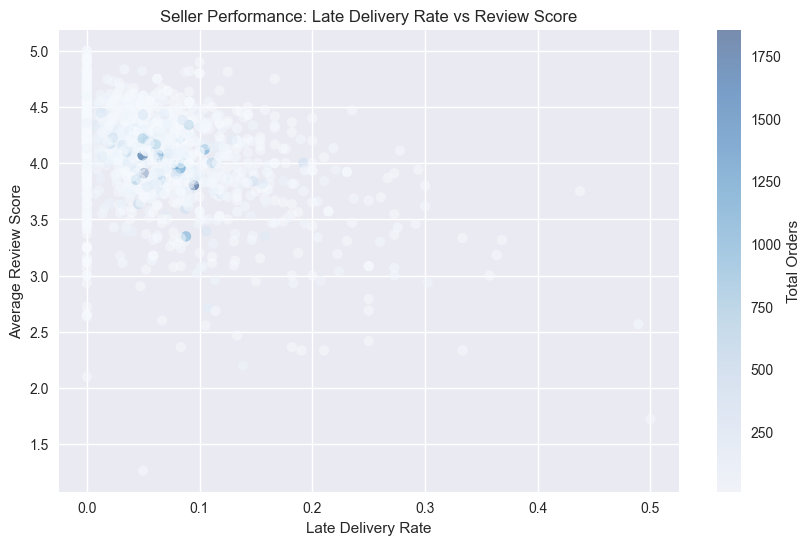

In [23]:
# Step 4: visualize seller performance
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    seller_performance['late_delivery_rate'],
    seller_performance['avg_review_score'],
    alpha=0.5,
    c=seller_performance['total_orders'],
    cmap='Blues',
    s=50
)

plt.colorbar(scatter, label='Total Orders')
ax.set_xlabel('Late Delivery Rate')
ax.set_ylabel('Average Review Score')
ax.set_title('Seller Performance: Late Delivery Rate vs Review Score')

plt.savefig('images/q2_q3_seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Q2 & Q3 - Seller Performance

**Key Insights:**
- 1,271 sellers have 10+ orders — enough data for reliable analysis
- Average late delivery rate: 6.28% — worst seller: 50%
- Average review score: 4.07/5 — worst seller: 1.72
- Clear negative correlation between late delivery rate and review score
- However, some sellers with 0% late deliveries still have low scores (3.25) — delivery is not the only factor
- Recommendation: flag sellers with late delivery rate > 30% and review score < 3 for immediate intervention

In [24]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [25]:
# Q4 - High price products vs revenue and units sold

# Merge items with products
items_products = items.merge(products, on='product_id', how='left')

# Merge with category translation
items_products = items_products.merge(
    category_translation, 
    on='product_category_name', 
    how='left'
)

# Merge with payments
items_products_payments = items_products.merge(
    payments[['order_id', 'payment_value']], 
    on='order_id', 
    how='left'
)

# Aggregate by category
category_analysis = items_products_payments.groupby('product_category_name_english').agg(
    total_units=('order_id', 'count'),
    avg_price=('price', 'mean'),
    total_revenue=('payment_value', 'sum')
).reset_index()

# Sort by avg price
category_analysis = category_analysis.sort_values('avg_price', ascending=False)

print(category_analysis.head(15))

              product_category_name_english  total_units    avg_price  \
14                                computers          220  1103.689136   
64    small_appliances_home_oven_and_coffee           78   627.509103   
45                        home_appliances_2          268   459.945187   
0                agro_industry_and_commerce          252   332.706151   
56                      musical_instruments          718   293.772604   
63                         small_appliances          701   286.614351   
34                          fixed_telephony          271   227.679926   
19                construction_tools_safety          199   210.942261   
70                            watches_gifts         6201   202.087292   
1                          air_conditioning          302   185.305894   
38                        furniture_bedroom          125   175.405440   
20                               cool_stuff         3987   166.117254   
51  kitchen_dining_laundry_garden_furniture        


## Q4 - High Price Products vs Revenue

**Key Insights:**
- Computers have the highest avg price ($1,103) but only 220 units sold — $279K revenue
- Watches & gifts ($202 avg) sold 6,201 units — generating significantly more revenue
- Cool stuff ($166 avg) sold 3,987 units — $779K revenue
- Volume drives revenue more than unit price in this dataset
- Recommendation: balance catalog between high-margin and high-volume products

In [26]:
# Q5 - Geolocation vs Reviews and Revenue

# Step 1: merge reviews with orders
reviews_orders = reviews[['order_id', 'review_score']].merge(
    orders[['order_id', 'customer_id']], 
    on='order_id', 
    how='left'
)

print(reviews_orders.shape)
print(reviews_orders.head())

(99224, 3)
                           order_id  review_score  \
0  73fc7af87114b39712e6da79b0a377eb             4   
1  a548910a1c6147796b98fdf73dbeba33             5   
2  f9e4b658b201a9f2ecdecbb34bed034b             5   
3  658677c97b385a9be170737859d3511b             5   
4  8e6bfb81e283fa7e4f11123a3fb894f1             5   

                        customer_id  
0  41dcb106f807e993532d446263290104  
1  8a2e7ef9053dea531e4dc76bd6d853e6  
2  e226dfed6544df5b7b87a48208690feb  
3  de6dff97e5f1ba84a3cd9a3bc97df5f6  
4  5986b333ca0d44534a156a52a8e33a83  


In [27]:
# Step 2: merge with customers
reviews_orders_customers = reviews_orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_state']], 
    on='customer_id', 
    how='left'
)

print(reviews_orders_customers.shape)
print(reviews_orders_customers.head())

(99224, 6)
                           order_id  review_score  \
0  73fc7af87114b39712e6da79b0a377eb             4   
1  a548910a1c6147796b98fdf73dbeba33             5   
2  f9e4b658b201a9f2ecdecbb34bed034b             5   
3  658677c97b385a9be170737859d3511b             5   
4  8e6bfb81e283fa7e4f11123a3fb894f1             5   

                        customer_id                customer_unique_id  \
0  41dcb106f807e993532d446263290104  68a5590b9926689be4e10f4ae2db21a8   
1  8a2e7ef9053dea531e4dc76bd6d853e6  64190b91b656ab8f37eb89b93dc84584   
2  e226dfed6544df5b7b87a48208690feb  1d47144362c14e94ccdd213e8ec277d5   
3  de6dff97e5f1ba84a3cd9a3bc97df5f6  c8cf6cb6b838dc7a33ed199b825e8616   
4  5986b333ca0d44534a156a52a8e33a83  d16000272660a1fef81482ad75ba572a   

   customer_zip_code_prefix customer_state  
0                      6030             SP  
1                     13380             SP  
2                     44571             BA  
3                     88735             SC  
4     

In [28]:
# Step 3: merge with payments
reviews_orders_payments = reviews_orders_customers.merge(
    payments[['order_id', 'payment_value']], 
    on='order_id', 
    how='left'
)

# Step 4: aggregate by state
geo_analysis = reviews_orders_payments.groupby('customer_state').agg(
    avg_review_score=('review_score', 'mean'),
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

geo_analysis = geo_analysis.sort_values('avg_review_score', ascending=False)

print(geo_analysis)

   customer_state  avg_review_score  total_revenue  total_orders
3              AP          4.217391       16192.42            67
2              AM          4.189542       27781.49           146
17             PR          4.176370      811569.64          5019
25             SP          4.172170     5985514.83         41472
26             TO          4.140000       61397.66           279
11             MS          4.139410      138871.47           713
10             MG          4.134491     1863484.56         11554
22             RS          4.126825      892369.24          5443
19             RN          4.073359      101973.69           480
23             SC          4.069767      616241.36          3609
20             RO          4.065385       60817.15           252
6              DF          4.061058      356040.62          2128
0              AC          4.047619       19680.62            81
7              ES          4.035885      314050.47          2006
8              GO        

In [29]:
# Step 5: merge with geolocation
geo_zip = geolocation.groupby('geolocation_state').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

geo_zip = geo_zip.rename(columns={'geolocation_state': 'customer_state'})

geo_analysis_final = geo_analysis.merge(geo_zip, on='customer_state', how='left')

print(geo_analysis_final.head(10))

  customer_state  avg_review_score  total_revenue  total_orders        lat  \
0             AP          4.217391       16192.42            67   0.086025   
1             AM          4.189542       27781.49           146  -3.349336   
2             PR          4.176370      811569.64          5019 -24.793607   
3             SP          4.172170     5985514.83         41472 -23.155308   
4             TO          4.140000       61397.66           279  -9.503700   
5             MS          4.139410      138871.47           713 -20.765006   
6             MG          4.134491     1863484.56         11554 -19.864647   
7             RS          4.126825      892369.24          5443 -29.679191   
8             RN          4.073359      101973.69           480  -5.856702   
9             SC          4.069767      616241.36          3609 -27.222486   

         lng  
0 -51.234304  
1 -60.537430  
2 -50.879662  
3 -47.084074  
4 -48.348661  
5 -54.532140  
6 -44.421615  
7 -52.032652  
8 -35.

In [30]:
geo_analysis_final.to_csv("data/clean/geo_analysis.csv", index=False)
print("Saved")

Saved


## Q5 - Geolocation vs Reviews and Revenue

**Key Insights:**
- São Paulo (SP) dominates revenue ($5.9M) with strong review score (4.17)
- Rio de Janeiro (RJ) is second in revenue ($2.1M) but has below average reviews (3.87)
- Northern states (AP, AM) have the best reviews but minimal revenue — small customer base
- Maranhão (MA) and Roraima (RR) have the worst review scores in the country
- Recommendation: investigate RJ logistics and seller quality — high revenue at risk due to low satisfaction

In [31]:
# Q6 - Categories with lowest revenue and worst reviews

# Merge items with products and category translation
items_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(category_translation, on='product_category_name', how='left')

# FIX: aggregate payments by order_id BEFORE merging to avoid revenue inflation
payments_per_order = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Merge with payments (already aggregated)
items_cat_payments = items_cat.merge(payments_per_order, on='order_id', how='left')

# Merge with reviews
items_cat_reviews = items_cat_payments.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Aggregate by category
category_performance = items_cat_reviews.groupby('product_category_name_english').agg(
    total_revenue=('payment_value', 'sum'),
    avg_review_score=('review_score', 'mean'),
    total_units=('order_id', 'count')
).reset_index()

# Filter categories with at least 50 units for relevance
category_performance = category_performance[category_performance['total_units'] >= 50]

# Sort by worst reviews
print(category_performance.sort_values('avg_review_score', ascending=True).head(10))


   product_category_name_english  total_revenue  avg_review_score  total_units
57              office_furniture      652016.50          3.493183         1701
30         fashion_male_clothing       17290.98          3.641221          132
34               fixed_telephony      207071.05          3.683206          265
27        fashio_female_clothing        5220.07          3.780000           50
4                          audio       60388.62          3.825485          365
47                  home_confort       84848.25          3.829885          437
19     construction_tools_safety       65691.03          3.844560          194
7                 bed_bath_table     1743998.80          3.895663        11270
39               furniture_decor     1443963.61          3.903493         8415
40         furniture_living_room      136853.98          3.904382          507


In [32]:
category_performance.to_csv("data/clean/category_performance.csv", index=False)
print("Saved — revenue corrected")

Saved — revenue corrected


## Q6 - Categories with Lowest Revenue and Worst Reviews

**Key Insights:**
- Office furniture has the worst review score (3.53) with $652K revenue at risk
- Bed, bath & table generates $1.74M but has low satisfaction (3.89) — highest risk category
- Furniture and home categories dominate the worst reviews — likely due to logistics complexity
- Fashion categories have poor reviews but low revenue impact
- Recommendation: prioritize logistics improvements for furniture and home categories

In [33]:
# Q7 - Payment method vs order value and reviews

# Merge payments with reviews
payments_reviews = payments.merge(
    reviews[['order_id', 'review_score']], 
    on='order_id', 
    how='left'
)

# Aggregate by payment type
payment_analysis = payments_reviews.groupby('payment_type').agg(
    total_orders=('order_id', 'nunique'),
    avg_order_value=('payment_value', 'mean'),
    avg_review_score=('review_score', 'mean'),
    total_revenue=('payment_value', 'sum')
).reset_index()

payment_analysis = payment_analysis.sort_values('avg_order_value', ascending=False)

print(payment_analysis)

  payment_type  total_orders  avg_order_value  avg_review_score  total_revenue
1  credit_card         76505       163.140977          4.087637    12594157.13
0       boleto         19784       144.986413          4.086631     2886679.49
2   debit_card          1528       142.396569          4.168084      218721.13
4      voucher          3866        65.499655          4.003804      381862.99
3  not_defined             3         0.000000          1.666667           0.00


In [34]:
payment_analysis.to_csv("data/clean/payment_analysis.csv", index=False)
print("Saved")

Saved


## Q7 - Payment Method vs Order Value and Reviews

**Key Insights:**
- Credit card dominates with 76,505 orders and $12.6M revenue
- All payment methods have similar review scores (~4.0) — payment method doesn't impact satisfaction
- Voucher orders have the lowest avg value ($65) — likely promotional purchases
- Debit card has the best review score (4.17) but represents only 1.5% of orders
- Recommendation: focus retention efforts on factors beyond payment method

In [35]:
# ML - Review Score Prediction

# Merge orders with items
ml_data = orders[['order_id', 'delivery_delay_days', 'is_late']].merge(
    items[['order_id', 'price', 'freight_value']], 
    on='order_id', how='left'
)

# Merge with payments
ml_data = ml_data.merge(
    payments[['order_id', 'payment_value', 'payment_installments']], 
    on='order_id', how='left'
)

# Merge with reviews
ml_data = ml_data.merge(
    reviews[['order_id', 'review_score']], 
    on='order_id', how='left'
)

# Merge with items-products for category
ml_data = ml_data.merge(
    items_cat[['order_id', 'product_category_name_english']], 
    on='order_id', how='left'
)

print(ml_data.shape)
print(ml_data.isnull().sum())

(165649, 9)
order_id                            0
delivery_delay_days              4319
is_late                             0
price                             833
freight_value                     833
payment_value                       9
payment_installments                9
review_score                     1945
product_category_name_english    3151
dtype: int64


In [36]:
# Handle nulls
ml_data['delivery_delay_days'] = ml_data['delivery_delay_days'].fillna(999)
ml_data['is_late'] = ml_data['is_late'].fillna(True)
ml_data['product_category_name_english'] = ml_data['product_category_name_english'].fillna('unknown')

# Drop remaining nulls
ml_data = ml_data.dropna()

print(ml_data.shape)
print(ml_data.isnull().sum())

(162881, 9)
order_id                         0
delivery_delay_days              0
is_late                          0
price                            0
freight_value                    0
payment_value                    0
payment_installments             0
review_score                     0
product_category_name_english    0
dtype: int64


In [37]:
# Create target variable
def classify_review(score):
    if score >= 4:
        return 0  # positive
    elif score == 3:
        return 1  # regular
    else:
        return 2  # negative

ml_data['review_class'] = ml_data['review_score'].apply(classify_review)

print(ml_data['review_class'].value_counts())
print(ml_data['review_class'].value_counts(normalize=True).round(2))

review_class
0    114880
2     33853
1     14148
Name: count, dtype: int64
review_class
0    0.71
2    0.21
1    0.09
Name: proportion, dtype: float64


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Features and target
X = ml_data[['delivery_delay_days', 'is_late', 'price', 
             'freight_value', 'payment_value', 
             'payment_installments', 'product_category_name_english']]

y = ml_data['review_class']

# Encode category
le = LabelEncoder()
X = X.copy()
X['product_category_name_english'] = le.fit_transform(X['product_category_name_english'])
X['is_late'] = X['is_late'].astype(int)

print(X.head())

   delivery_delay_days  is_late   price  freight_value  payment_value  \
0                 -8.0        0   29.99           8.72          18.12   
1                 -8.0        0   29.99           8.72           2.00   
2                 -8.0        0   29.99           8.72          18.59   
3                 -6.0        0  118.70          22.76         141.46   
4                -18.0        0  159.90          19.22         179.12   

   payment_installments  product_category_name_english  
0                   1.0                             49  
1                   1.0                             49  
2                   1.0                             49  
3                   1.0                             59  
4                   3.0                              5  


In [39]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, 
      target_names=['Positive', 'Regular', 'Negative']))

              precision    recall  f1-score   support

    Positive       0.89      0.98      0.93     23026
     Regular       0.88      0.46      0.60      2729
    Negative       0.91      0.78      0.84      6822

    accuracy                           0.89     32577
   macro avg       0.89      0.74      0.79     32577
weighted avg       0.89      0.89      0.88     32577



## ML - Review Score Prediction (Random Forest)

**Model:** Random Forest Classifier — multiclass (Positive / Regular / Negative)
**Train/Test split:** 80% / 20%

| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Positive (4-5) | 89% | 98% | 93% |
| Regular (3) | 88% | 46% | 60% |
| Negative (1-2) | 91% | 78% | 84% |
| **Overall Accuracy** | | | **89%** |

**Key Insights:**
- Model achieves 89% overall accuracy
- Negative reviews detected with 91% precision and 78% recall
- Regular (score 3) is hardest to predict — genuinely ambiguous class
- Recall on negatives (78%) means model catches 8 in 10 bad experiences before they happen
- Recommendation: use model to flag high-risk orders for proactive customer support

                feature  importance
4         payment_value    0.237059
2                 price    0.195402
3         freight_value    0.189450
0   delivery_delay_days    0.186684
6      product_category    0.109523
5  payment_installments    0.066758
1               is_late    0.015124


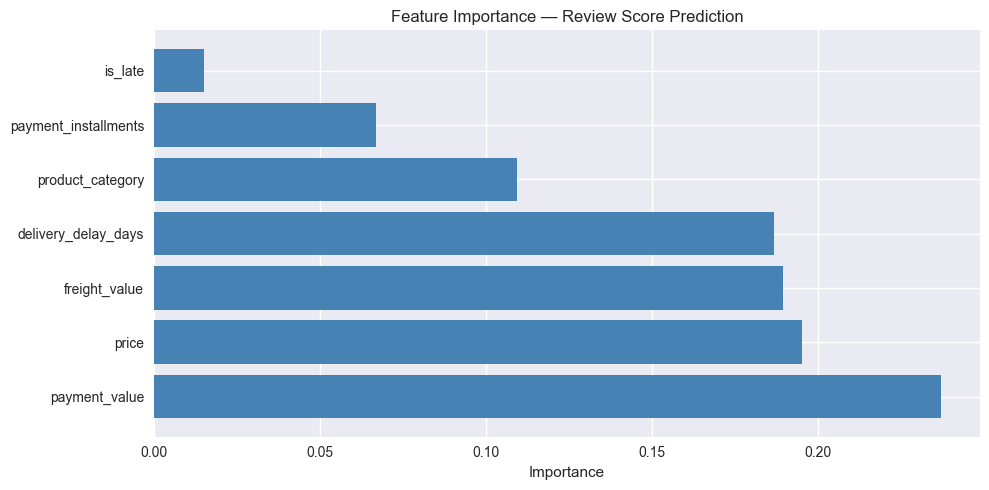

In [40]:
# Feature importance
import matplotlib.pyplot as plt

feature_names = ['delivery_delay_days', 'is_late', 'price', 
                 'freight_value', 'payment_value', 
                 'payment_installments', 'product_category']

importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(fi_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Review Score Prediction')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('images/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature Importance:**
- payment_value is the strongest predictor — high spend = higher expectations
- freight_value confirms cost of shipping impacts satisfaction
- delivery_delay_days matters more than is_late — severity beats binary flag
- is_late alone is a weak predictor

**Business Recommendations:**
- Focus on high-price products — customers who pay more have higher expectations. 
  Improve product descriptions and photos to reduce the gap between expectation and reality.
- Membership program (like Rappi Prime) with freight discounts — freight is the 3rd strongest predictor of satisfaction.
- Prioritize logistics improvements for furniture and home categories — worst reviews + highest revenue at risk.
- Use the model to flag high-risk orders proactively — contact customers before they leave a negative review.
  The model detects 8 in 10 negative reviews with 91% precision.

In [41]:
for name, df in datasets.items():
    print(f"=== {name} ===")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")
    print()

=== orders ===
  order_id: str
  customer_id: str
  order_status: str
  order_purchase_timestamp: datetime64[us]
  order_approved_at: datetime64[us]
  order_delivered_carrier_date: datetime64[us]
  order_delivered_customer_date: datetime64[us]
  order_estimated_delivery_date: datetime64[us]
  delivery_delay_days: float64
  is_late: bool

=== customers ===
  customer_id: str
  customer_unique_id: str
  customer_zip_code_prefix: int64
  customer_city: str
  customer_state: str

=== items ===
  order_id: str
  order_item_id: int64
  product_id: str
  seller_id: str
  shipping_limit_date: datetime64[us]
  price: float64
  freight_value: float64

=== payments ===
  order_id: str
  payment_sequential: int64
  payment_type: str
  payment_installments: int64
  payment_value: float64

=== reviews ===
  review_id: str
  order_id: str
  review_score: int64
  review_comment_title: str
  review_comment_message: str
  review_creation_date: datetime64[us]
  review_answer_timestamp: datetime64[us]

==